# Geospatial Data Visualization
This notebook visualizes the data found in the `data/` directory, including GPS probe data (HPD) and street network data.

**Note:** Ensure you are running this notebook in the `here_env` environment.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

# Print environment to verify
print(f"Active Environment Path: {sys.prefix}")

# Attempt to import geospatial libraries
HAS_GEOPANDAS = False
try:
    import geopandas as gpd
    from shapely import wkt
    HAS_GEOPANDAS = True
    print("Geopandas and Shapely are available.")
except ImportError:
    print("Geopandas/Shapely not found. Using custom parsing and Matplotlib for visualization.")

Active Environment Path: d:\miniconda3\envs\here_env
Geopandas and Shapely are available.


In [5]:
# 1. Load Bounding Box
bbox_file = os.path.join('data', 'Kosovo_bounding_box.txt')
bbox = None

if os.path.exists(bbox_file):
    with open(bbox_file, 'r') as f:
        # Expected format: "Kosovo:\n[min_x, min_y, max_x, max_y]"
        content = f.read()
        print("Bounding Box File Content:")
        print(content)
        
        try:
            # simple parsing
            import re
            match = re.search(r'\[(.*?)\]', content)
            if match:
                bbox_vals = match.group(1).split(',')
                bbox = [float(x.strip()) for x in bbox_vals]
                print(f"Parsed Bounding Box: {bbox}")
        except Exception as e:
            print(f"Error parsing bounding box: {e}")
else:
    print(f"File not found: {bbox_file}")

Bounding Box File Content:
Kosovo:
[21.088588, 42.571255, 21.188588, 42.671255]
Parsed Bounding Box: [21.088588, 42.571255, 21.188588, 42.671255]


Loading data\Kosovo_HPD\XKO_HPD_week_2.csv...
Total rows: 299073


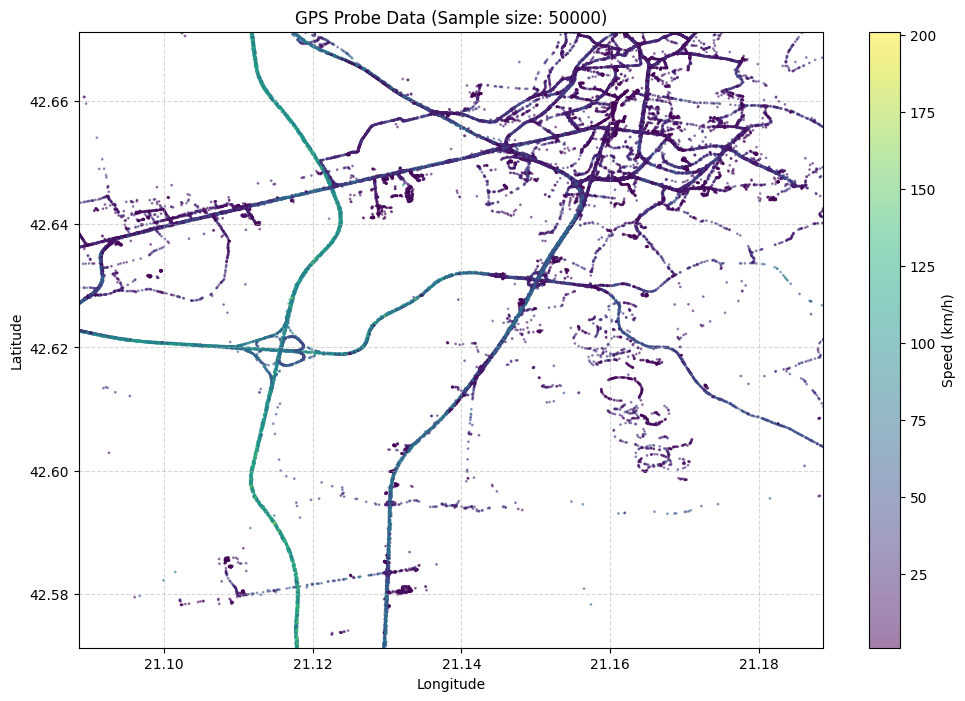

In [12]:
# 2. Visualize Historical Probe Data (HPD)
# Loads a sample of the GPS traces and plots them relative to speed.

hpd_path = os.path.join('data', 'Kosovo_HPD', 'XKO_HPD_week_2.csv')

if os.path.exists(hpd_path):
    print(f"Loading {hpd_path}...")
    # Read a sample if the file is very large, or full file if manageable.
    # Given typical hackathon sizes, we'll read it all but sample for plotting.
    df_hpd = pd.read_csv(hpd_path)
    print(f"Total rows: {len(df_hpd)}")
    
    # Sample for visualization to keep performance high
    sample_size = min(50000, len(df_hpd))
    df_sample = df_hpd.sample(n=sample_size)
    
    plt.figure(figsize=(12, 8))
    # Scatter plot: Longitude vs Latitude, colored by Speed
    sc = plt.scatter(df_sample['longitude'], df_sample['latitude'], 
                     c=df_sample['speed'], cmap='viridis', 
                     s=1, alpha=0.5)
    plt.colorbar(sc, label='Speed (km/h)')
    plt.title(f'GPS Probe Data (Sample size: {sample_size})')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    
    if bbox:
        # Set limits based on bounding box [min_x, min_y, max_x, max_y]
        plt.xlim(bbox[0], bbox[2])
        plt.ylim(bbox[1], bbox[3])
    else:
        plt.axis('equal')
        
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

else:
    print(f"HPD file not found at {hpd_path}")

Reading GeoPackage: data\Kosovo_s_nav_streets\Kosovo.gpkg


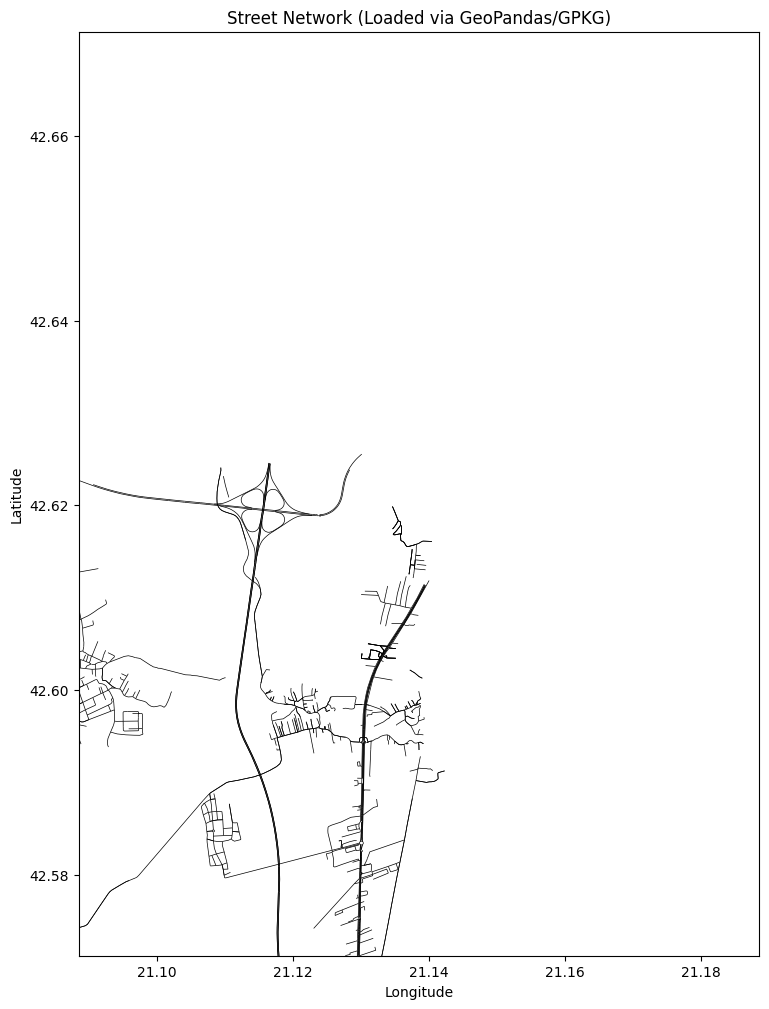

In [ ]:
# 3. Visualize Street Network
# Loads street vectors. Uses GeoPandas if available, else standard Pandas with manual WKT parsing.

streets_gpkg = os.path.join('data', 'Kosovo_nav_streets', 'nav_kosovo.gpkg')
streets_csv = os.path.join('data', 'Kosovo_nav_streets', 'nav_kosovo.csv')

fig, ax = plt.subplots(figsize=(12, 12))

if HAS_GEOPANDAS and os.path.exists(streets_gpkg):
    print(f"Reading GeoPackage: {streets_gpkg}")
    gdf = gpd.read_file(streets_gpkg)
    gdf.plot(ax=ax, color='black', linewidth=0.5)
    ax.set_title("Street Network (Loaded via GeoPandas/GPKG)")

elif os.path.exists(streets_csv):
    print(f"Reading CSV: {streets_csv}")
    df_streets = pd.read_csv(streets_csv)
    
    if HAS_GEOPANDAS:
        # Parse WKT using Shapely
        print("Parsing WKT Geometry...")
        df_streets['geometry'] = df_streets['geom'].apply(wkt.loads)
        gdf = gpd.GeoDataFrame(df_streets, geometry='geometry')
        gdf.plot(ax=ax, color='black', linewidth=0.5)
        ax.set_title("Street Network (Loaded via CSV + Shapely)")
    else:
        # Manual parsing fallback
        print("Manual WKT parsing (slow)...")
        count = 0
        limit = 5000 # Limit to prevent freezing on slow plotting
        
        for wkt_str in df_streets['geom']:
            # Expected: "LINESTRING (x y, x y, ...)"
            try:
                raw_coords = wkt_str.replace("LINESTRING", "").replace("(", "").replace(")", "").strip()
                points = raw_coords.split(",")
                xs = []
                ys = []
                for p in points:
                    coords = p.strip().split()
                    if len(coords) >= 2:
                        xs.append(float(coords[0]))
                        ys.append(float(coords[1]))
                ax.plot(xs, ys, color='black', linewidth=0.5, alpha=0.6)
                
                count += 1
                if count >= limit:
                    print(f"Stopped plotting after {limit} segments for performance.")
                    break
            except Exception as e:
                continue
        ax.set_title("Street Network (Manual Parsing)")

if bbox:
    ax.set_xlim(bbox[0], bbox[2])
    ax.set_ylim(bbox[1], bbox[3])
else:
    ax.set_aspect('equal')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Plotting streets by Functional Class...


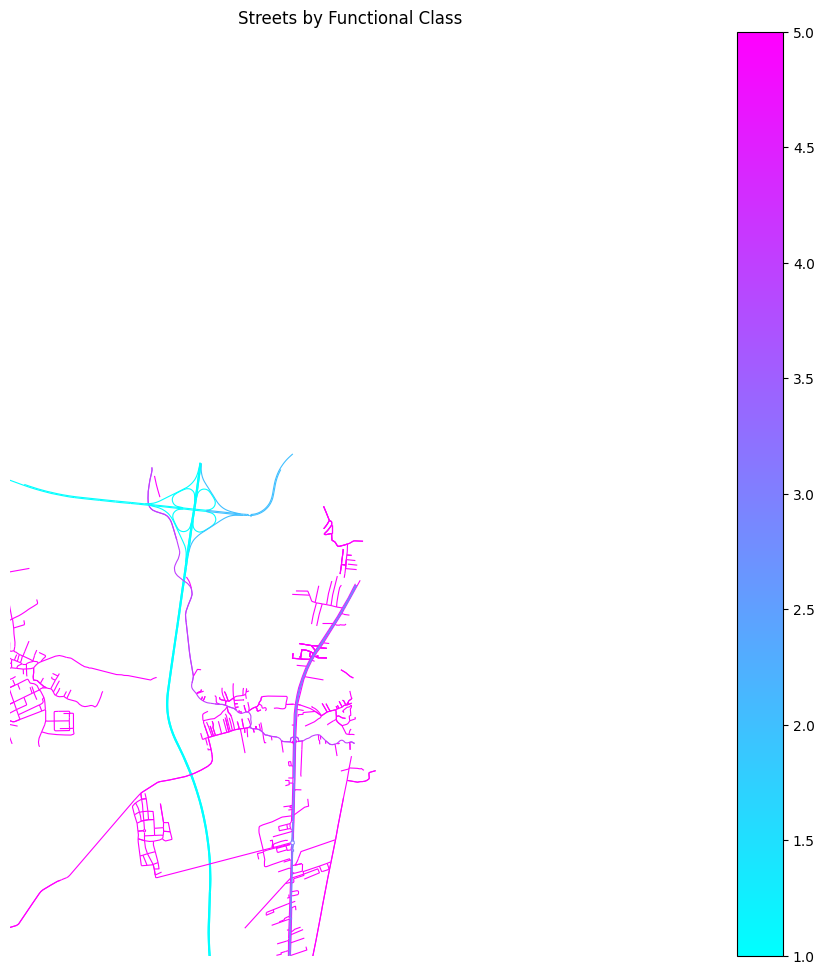

In [8]:
# 4. Advanced: Streets colored by Functional Class
# Functional Class (func_class) determines the hierarchy of the road (1=High, 5=Low)

if 'gdf' in locals() and 'func_class' in gdf.columns:
    print("Plotting streets by Functional Class...")
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Plot with legend
    try:
        gdf.plot(column='func_class', ax=ax, cmap='cool', legend=True, linewidth=0.8)
        ax.set_title("Streets by Functional Class")
        if bbox:
            ax.set_xlim(bbox[0], bbox[2])
            ax.set_ylim(bbox[1], bbox[3])
        # Hide axis for cleaner map
        ax.set_axis_off()
        plt.show()
    except Exception as e:
        print(f"Error plotting advanced map: {e}")

elif 'df_streets' in locals() and 'func_class' in df_streets.columns:
    print("Geopandas not active. Skipping categorical geometric plot.")
else:
    print("Functional class column not found.")

Loading VPD data from data\Kosovo_VPD\Kosovo_VPD.csv...
Loaded 5000 rows for visualization.
Converting WKT to Geometry...


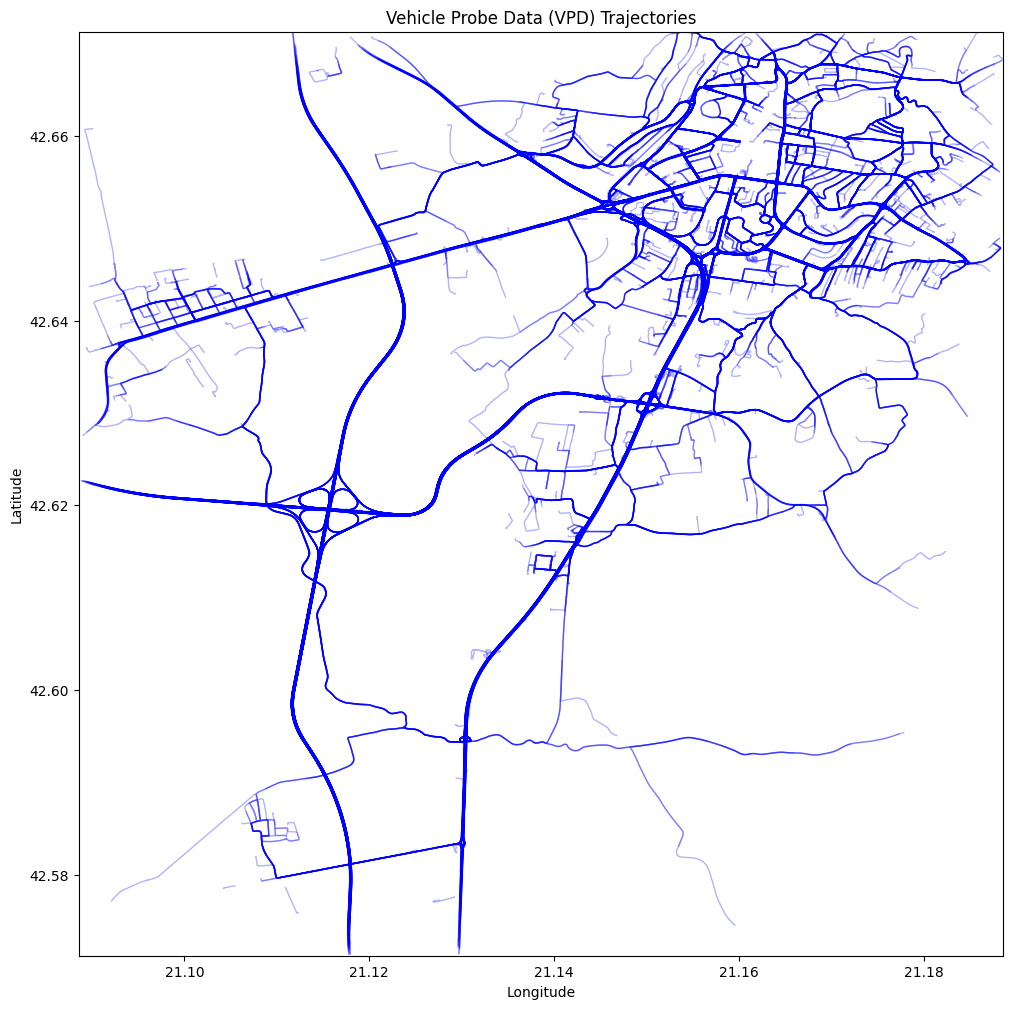

In [ ]:
# 5. Visualize Vehicle Probe Data (VPD)
# Loads VPD trajectories. 
# "path" column contains WKT LINESTRINGS.

vpd_path = os.path.join('data', 'Kosovo_VPD', 'Kosovo_VPD.csv')

if os.path.exists(vpd_path):
    print(f"Loading VPD data from {vpd_path}...")
    # Read a sample to manage memory load
    # Using 'path' column for geometry
    try:
        # Read random sample using chunks if file is huge, or just read_csv with nrows if just for vis
        # Since we want a random sample of the WHOLE file, typically we read headers then skip rows, 
        # but for simplicity in a notebook let's try reading a chunk or limiting rows.
        
        # We'll read the first 10,000 rows as a quick visual sample. 
        # Adjust 'nrows' if you want more data (warning: parsing WKT is slow).
        df_vpd = pd.read_csv(vpd_path, nrows=5000) 
        print(f"Loaded {len(df_vpd)} rows for visualization.")
        
        fig, ax = plt.subplots(figsize=(12, 12))
        
        if HAS_GEOPANDAS and 'path' in df_vpd.columns:
            print("Converting WKT to Geometry...")
            df_vpd['geometry'] = df_vpd['path'].apply(wkt.loads)
            gdf_vpd = gpd.GeoDataFrame(df_vpd, geometry='geometry')
            
            # Plot
            gdf_vpd.plot(ax=ax, color='blue', alpha=0.3, linewidth=1, label='VPD Trajectories')
            ax.set_title("Vehicle Probe Data (VPD) Trajectories")
            
        elif 'path' in df_vpd.columns:
            print("Manual WKT parsing for VPD...")
            for wkt_str in df_vpd['path']:
                try:
                    # simplistic parse for LINESTRING (x y, x y)
                    if not isinstance(wkt_str, str): continue
                    coords_text = wkt_str.replace("LINESTRING", "").replace("(", "").replace(")", "").strip()
                    points = coords_text.split(",")
                    xs = []
                    ys = []
                    for p in points:
                        coords = p.strip().split()
                        if len(coords) >= 2:
                            xs.append(float(coords[0]))
                            ys.append(float(coords[1]))
                    ax.plot(xs, ys, color='blue', alpha=0.3, linewidth=1)
                except:
                    pass
            ax.set_title("Vehicle Probe Data (VPD) Trajectories (Manual Parse)")
            
        else:
            print("Column 'path' not found in VPD data.")
            
        if bbox:
            ax.set_xlim(bbox[0], bbox[2])
            ax.set_ylim(bbox[1], bbox[3])
        else:
            ax.set_aspect('equal')
            
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.show()

    except Exception as e:
        print(f"Error visualizing VPD: {e}")
else:
    print(f"VPD file not found at {vpd_path}")